# Configuración del Entorno e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
import time
import json
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, average_precision_score, 
                             precision_recall_curve, f1_score, recall_score, 
                             accuracy_score)

from mealpy import FloatVar, GWO, MFO
from scipy.stats import wilcoxon, shapiro, t as t_dist

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")

# ============================================================
# REPRODUCIBILIDAD GLOBAL
# ============================================================
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# Directorio de salida para figuras y resultados
OUTPUT_DIR = "/kaggle/working/resultados_gwo_mfo"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"XGBoost version: {xgb.__version__}")
print(f"Directorio de salida: {OUTPUT_DIR}")

XGBoost version: 3.2.0
Directorio de salida: /kaggle/working/resultados_gwo_mfo


# Carga y Preprocesamiento de Datos

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mgoldyuwu/modelo-hibrido/default of credit card clients.csv', sep=',', skiprows=1)

if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'target'}, inplace=True)

if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dimensiones del dataset: {df.shape}")
print(f"Distribución de clases:\n{df['target'].value_counts()}")
print(f"Prevalencia clase positiva: {df['target'].mean():.4f}")

Dimensiones del dataset: (30000, 24)
Distribución de clases:
target
0    23364
1     6636
Name: count, dtype: int64
Prevalencia clase positiva: 0.2212


# División Train/Test y Cálculo de Scale Pos Weight

In [3]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=GLOBAL_SEED, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Clase 0 (train): {neg} | Clase 1 (train): {pos}")
print(f"Scale Pos Weight: {base_scale_pos_weight:.4f}")

Train: (24000, 23) | Test: (6000, 23)
Clase 0 (train): 18691 | Clase 1 (train): 5309
Scale Pos Weight: 3.5206


# Función de Evaluación Completa (con TP/FP/TN/FN)

In [4]:
def evaluate_model(y_true, y_pred, y_prob, model_name="Modelo"):
    """Evalúa un modelo y retorna todas las métricas + matriz de confusión."""
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"--- {model_name} ---")
    print(f"PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | "
          f"F1: {f1:.4f} | Recall: {rec:.4f} | Acc: {acc:.4f}")
    print(f"TP={tp} | FP={fp} | TN={tn} | FN={fn}")
    
    return {
        "pr_auc": pr_auc, "roc_auc": roc_auc, "f1": f1,
        "recall": rec, "accuracy": acc,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn)
    }

# Entrenamiento del Modelo Base XGBoost

In [5]:
t0 = time.time()
model_base = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=base_scale_pos_weight,
    tree_method='hist', device='cuda', eval_metric='aucpr',
    random_state=GLOBAL_SEED, verbosity=0
)
model_base.fit(X_train, y_train, verbose=False)
t_base = time.time() - t0

y_pred_base = model_base.predict(X_test)
y_prob_base = model_base.predict_proba(X_test)[:, 1]
metrics_base = evaluate_model(y_test, y_pred_base, y_prob_base, "MODELO BASE")
print(f"⏱️ Tiempo entrenamiento base: {t_base:.1f}s")

--- MODELO BASE ---
PR-AUC: 0.5404 | ROC-AUC: 0.7677 | F1: 0.5290 | Recall: 0.5878 | Acc: 0.7685
TP=780 | FP=842 | TN=3831 | FN=547
⏱️ Tiempo entrenamiento base: 1.3s


# Visualización del Modelo Base

💾 Figura guardada: /kaggle/working/resultados_gwo_mfo/eval_BASE.png


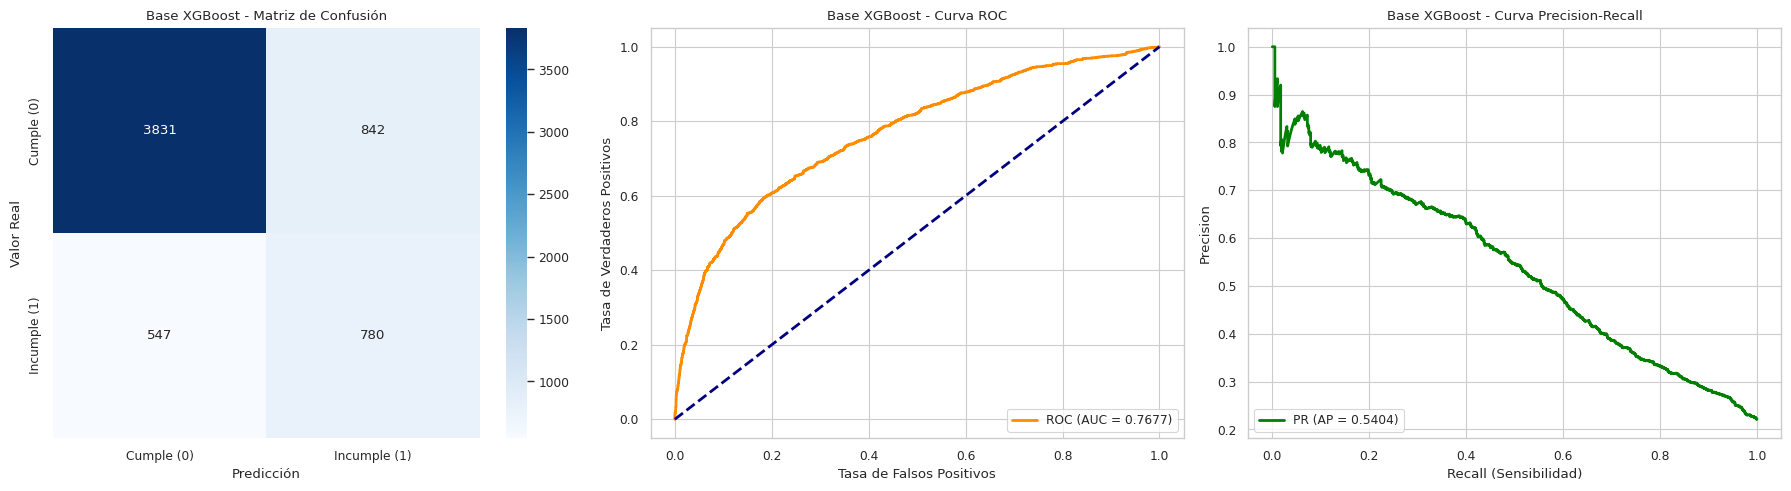

In [6]:
def plot_model_evaluation(y_true, y_pred, y_prob, title_prefix="Modelo", 
                          save_path=None):
    """Genera matriz de confusión, ROC y PR. Opcionalmente guarda."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Cumple (0)', 'Incumple (1)'],
                yticklabels=['Cumple (0)', 'Incumple (1)'])
    axes[0].set_title(f'{title_prefix} - Matriz de Confusión')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
                 label=f'ROC (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'{title_prefix} - Curva ROC')
    axes[1].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    axes[2].plot(recall, precision, color='green', lw=2, 
                 label=f'PR (AP = {pr_auc:.4f})')
    axes[2].set_xlabel('Recall (Sensibilidad)')
    axes[2].set_ylabel('Precision')
    axes[2].set_title(f'{title_prefix} - Curva Precision-Recall')
    axes[2].legend(loc="lower left")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Figura guardada: {save_path}")
    plt.show()

plot_model_evaluation(y_test, y_pred_base, y_prob_base, "Base XGBoost",
                      save_path=f"{OUTPUT_DIR}/eval_BASE.png")

# Función Objetivo y Límites para GWO

In [7]:
LB = [100, 3, 0.01, 0.6, 0.6, 2.0]
UB = [600, 10, 0.15, 1.0, 1.0, 5.0]

MIN_RECALL_THRESHOLD = 0.55
PENALTY_LAMBDA = 0.8  # ← λ = 0.8 (NO 10)

def extract_params(solution):
    """Extrae hiperparámetros con redondeo correcto (P-1)."""
    params = {
        "n_estimators": int(round(solution[0])),
        "max_depth": int(round(solution[1])),
        "learning_rate": float(solution[2]),
        "subsample": float(solution[3]),
        "colsample_bytree": float(solution[4]),
        "scale_pos_weight": float(solution[5])
    }
    # P-7: Verificación de rango
    for i, (key, lb, ub) in enumerate(zip(
        ["n_estimators","max_depth","learning_rate",
         "subsample","colsample_bytree","scale_pos_weight"], LB, UB)):
        val = params[key]
        if not (lb <= val <= ub):
            print(f"⚠️ {key}={val} fuera de [{lb},{ub}], clampeando.")
            params[key] = max(lb, min(ub, val))
    return params

def make_objective(seed_val):
    """Crea función objetivo con semilla específica (P-8: fuera del loop)."""
    def obj(solution):
        params = extract_params(solution)
        params.update({
            "tree_method": 'hist', "device": 'cuda', "eval_metric": 'aucpr',
            "early_stopping_rounds": 30, "random_state": seed_val, "verbosity": 0
        })
        
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed_val)
        scores = []
        
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr = X_train.iloc[train_idx]
            X_val = X_train.iloc[val_idx]
            y_tr = y_train.iloc[train_idx]
            y_val = y_train.iloc[val_idx]
            
            m = xgb.XGBClassifier(**params)
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            
            y_p = m.predict(X_val)
            y_p_prob = m.predict_proba(X_val)[:, 1]
            
            pr_auc = average_precision_score(y_val, y_p_prob)
            f1 = f1_score(y_val, y_p)
            rec = recall_score(y_val, y_p)
            
            combined = np.sqrt(pr_auc * f1)  # Media geométrica
            penalty = max(0.0, (MIN_RECALL_THRESHOLD - rec) * PENALTY_LAMBDA)
            scores.append((1.0 - combined) + penalty)
            
        return np.mean(scores)
    return obj

# Función objetivo principal (semilla fija = GLOBAL_SEED)
objective_function_gwo = make_objective(GLOBAL_SEED)

problem_dict = {
    "obj_func": objective_function_gwo,
    "bounds": FloatVar(lb=LB, ub=UB, name="xgb_hyperparams"),
    "minmax": "min",
}

# Optimización GWO (20 Iteraciones)

In [8]:
np.random.seed(GLOBAL_SEED)  # P-9: Semilla explícita para Mealpy
t0 = time.time()
gwo_20_model = GWO.OriginalGWO(epoch=20, pop_size=20)
gwo_20_best = gwo_20_model.solve(problem_dict)
t_gwo20 = time.time() - t0

print(f"✅ GWO-20 completado en {t_gwo20:.1f}s")
print(f"Mejor fitness: {gwo_20_best.target.fitness:.4f}")
print(f"OFEs reales: 20 × 20 × 3 = {20*20*3}")

best_params_20 = extract_params(gwo_20_best.solution)
print(f"Mejores hiperparámetros: {best_params_20}")

2026/07/23 11:51:28 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=20)
2026/07/23 11:52:08 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.4463760636985028, Global best: 0.4463760636985028, Runtime: 20.38063 seconds
2026/07/23 11:52:30 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4463760636985028, Global best: 0.4463760636985028, Runtime: 22.50589 seconds
2026/07/23 11:52:53 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4463760636985028, Global best: 0.4463760636985028, Runtime: 22.33478 seconds
2026/07/23 11:53:12 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4463760636985028, Global best: 0.4463760636985028, Runtime: 19.32155 seconds
2026/07/23 11:53:36 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44620274867275594, Global best: 0.44620274867275594, Run

✅ GWO-20 completado en 444.4s
Mejor fitness: 0.4450
OFEs reales: 20 × 20 × 3 = 1200
Mejores hiperparámetros: {'n_estimators': 380, 'max_depth': 6, 'learning_rate': 0.033692492217936326, 'subsample': 0.7634615573452121, 'colsample_bytree': 1.0, 'scale_pos_weight': 2.8902250907832765}


# Entrenamiento Final GWO (20 Iteraciones)

--- GWO (20) ---
PR-AUC: 0.5484 | ROC-AUC: 0.7731 | F1: 0.5382 | Recall: 0.5652 | Acc: 0.7855
TP=750 | FP=710 | TN=3963 | FN=577
💾 Figura guardada: /kaggle/working/resultados_gwo_mfo/eval_GWO_20.png


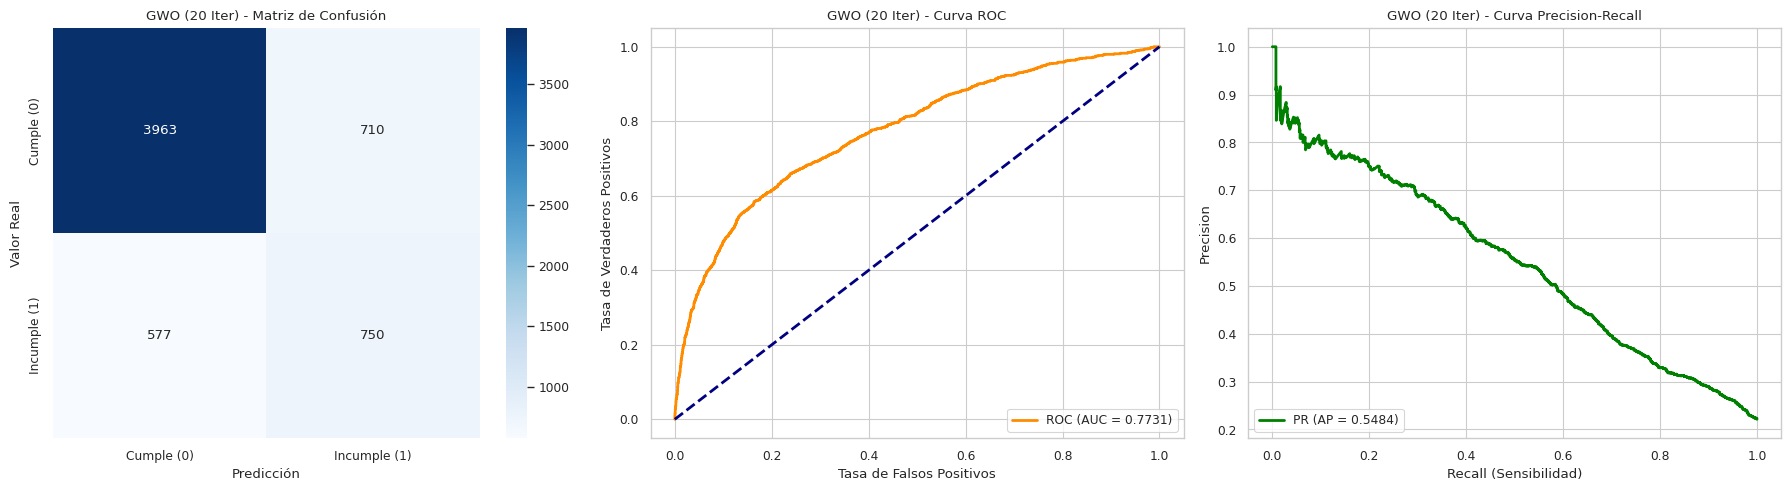

In [9]:
model_gwo_20 = xgb.XGBClassifier(
    **best_params_20, tree_method='hist', device='cuda',
    eval_metric='aucpr', random_state=GLOBAL_SEED, verbosity=0
)
model_gwo_20.fit(X_train, y_train, verbose=False)

y_pred_gwo_20 = model_gwo_20.predict(X_test)
y_prob_gwo_20 = model_gwo_20.predict_proba(X_test)[:, 1]
metrics_gwo_20 = evaluate_model(y_test, y_pred_gwo_20, y_prob_gwo_20, "GWO (20)")

plot_model_evaluation(y_test, y_pred_gwo_20, y_prob_gwo_20, "GWO (20 Iter)",
                      save_path=f"{OUTPUT_DIR}/eval_GWO_20.png")

# Optimización GWO (50 Iteraciones)

In [10]:
np.random.seed(GLOBAL_SEED)
t0 = time.time()
gwo_50_model = GWO.OriginalGWO(epoch=50, pop_size=20)
gwo_50_best = gwo_50_model.solve(problem_dict)
t_gwo50 = time.time() - t0

print(f"✅ GWO-50 completado en {t_gwo50:.1f}s")
print(f"Mejor fitness: {gwo_50_best.target.fitness:.4f}")
print(f"OFEs reales: 50 × 20 × 3 = {50*20*3}")

best_params_50 = extract_params(gwo_50_best.solution)
print(f"Mejores hiperparámetros: {best_params_50}")

2026/07/23 11:58:54 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=50, pop_size=20)
2026/07/23 11:59:30 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.45186399269393035, Global best: 0.45186399269393035, Runtime: 16.72636 seconds
2026/07/23 11:59:47 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4479055659887092, Global best: 0.4479055659887092, Runtime: 16.49985 seconds
2026/07/24 12:00:05 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44764231661263526, Global best: 0.44764231661263526, Runtime: 17.89174 seconds
2026/07/24 12:00:23 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4470037852707142, Global best: 0.4470037852707142, Runtime: 18.19744 seconds
2026/07/24 12:00:44 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4470037852707142, Global best: 0.4470037852707142, R

✅ GWO-50 completado en 957.4s
Mejor fitness: 0.4432
OFEs reales: 50 × 20 × 3 = 3000
Mejores hiperparámetros: {'n_estimators': 338, 'max_depth': 5, 'learning_rate': 0.03915765678757297, 'subsample': 0.6557667521760663, 'colsample_bytree': 0.8129299993931957, 'scale_pos_weight': 2.8368482285923022}


# Entrenamiento Final GWO (50 Iteraciones)

--- GWO (50) ---
PR-AUC: 0.5536 | ROC-AUC: 0.7792 | F1: 0.5494 | Recall: 0.5780 | Acc: 0.7903
TP=767 | FP=698 | TN=3975 | FN=560
💾 Figura guardada: /kaggle/working/resultados_gwo_mfo/eval_GWO_50.png


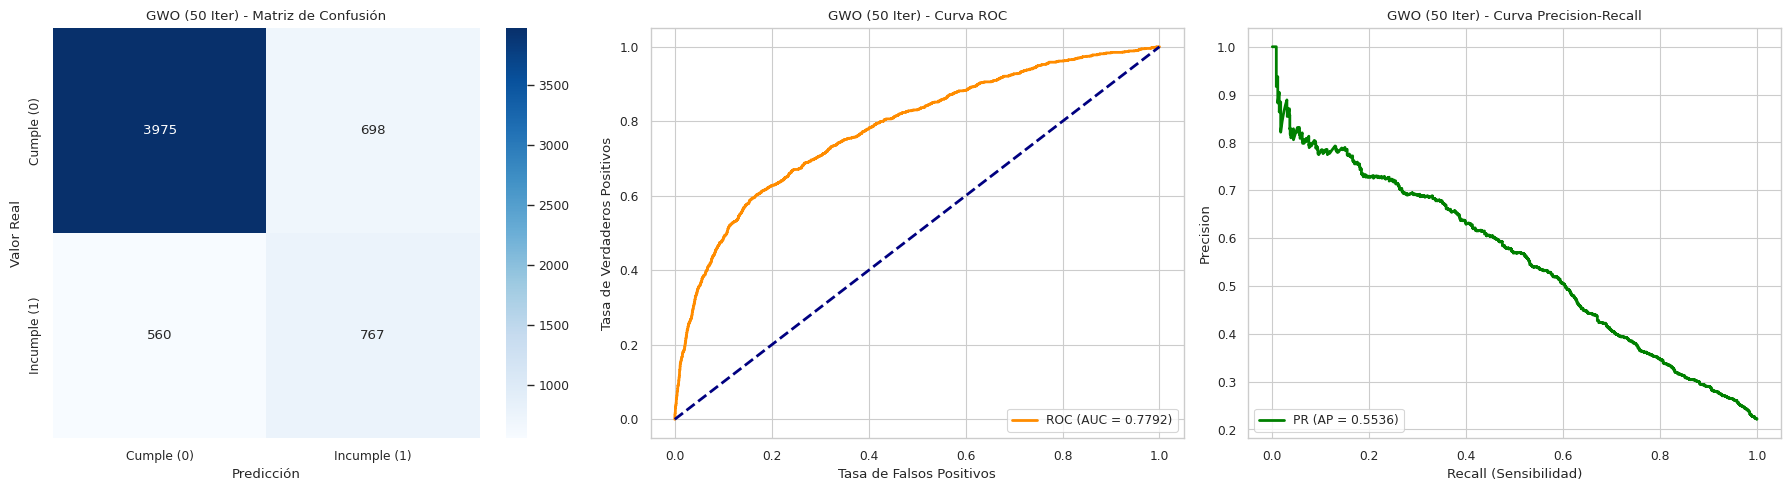

In [11]:
model_gwo_50 = xgb.XGBClassifier(
    **best_params_50, tree_method='hist', device='cuda',
    eval_metric='aucpr', random_state=GLOBAL_SEED, verbosity=0
)
model_gwo_50.fit(X_train, y_train, verbose=False)

y_pred_gwo_50 = model_gwo_50.predict(X_test)
y_prob_gwo_50 = model_gwo_50.predict_proba(X_test)[:, 1]
metrics_gwo_50 = evaluate_model(y_test, y_pred_gwo_50, y_prob_gwo_50, "GWO (50)")

plot_model_evaluation(y_test, y_pred_gwo_50, y_prob_gwo_50, "GWO (50 Iter)",
                      save_path=f"{OUTPUT_DIR}/eval_GWO_50.png")

# Optimización Híbrida GWO + MFO (20 + 20)

In [12]:
def run_hybrid(gwo_epochs, mfo_epochs, pop_size, seed, label=""):
    """Ejecuta la estrategia híbrida GWO→MFO con todas las verificaciones."""
    np.random.seed(seed)
    
    # FASE 1: GWO Global
    print(f"🐺 FASE 1: GWO ({gwo_epochs} épocas) - {label}")
    t0 = time.time()
    gwo = GWO.OriginalGWO(epoch=gwo_epochs, pop_size=pop_size)
    gwo_best = gwo.solve(problem_dict)
    t_gwo = time.time() - t0
    print(f"   Fitness GWO: {gwo_best.target.fitness:.4f} ({t_gwo:.1f}s)")
    
    # FASE 2: MFO Local
    best_gwo = gwo_best.solution
    margin = 0.20
    LB_loc = [max(lb, b - (ub - lb) * margin) for lb, ub, b in zip(LB, UB, best_gwo)]
    UB_loc = [min(ub, b + (ub - lb) * margin) for lb, ub, b in zip(LB, UB, best_gwo)]
    
    # P-17: Verificar que LB < UB
    for i, (l, u) in enumerate(zip(LB_loc, UB_loc)):
        if l >= u:
            print(f"⚠️ LB_loc[{i}]={l:.4f} >= UB_loc[{i}]={u:.4f}, ajustando.")
            mid = (l + u) / 2
            LB_loc[i] = mid - 0.01
            UB_loc[i] = mid + 0.01
    
    print(f"🦋 FASE 2: MFO ({mfo_epochs} épocas) - {label}")
    print(f"   LB_local: {np.round(LB_loc, 4)}")
    print(f"   UB_local: {np.round(UB_loc, 4)}")
    
    prob_local = {
        "obj_func": make_objective(seed),
        "bounds": FloatVar(lb=LB_loc, ub=UB_loc, name="xgb_local"),
        "minmax": "min",
    }
    
    np.random.seed(seed + 1)  # Semilla diferente para MFO
    t0 = time.time()
    mfo = MFO.OriginalMFO(epoch=mfo_epochs, pop_size=pop_size)
    mfo_best = mfo.solve(prob_local)
    t_mfo = time.time() - t0
    print(f"   Fitness MFO: {mfo_best.target.fitness:.4f} ({t_mfo:.1f}s)")
    
    ofe_total = (gwo_epochs + mfo_epochs) * pop_size * 3
    print(f"   OFEs totales: ({gwo_epochs}+{mfo_epochs}) × {pop_size} × 3 = {ofe_total}")
    
    return extract_params(mfo_best.solution), t_gwo + t_mfo, ofe_total

# Híbrido 20+20
best_params_hybrid_20, t_hyb20, ofe_hyb20 = run_hybrid(
    gwo_epochs=20, mfo_epochs=20, pop_size=20, 
    seed=GLOBAL_SEED, label="Híbrido (20+20)"
)
print(f"Mejores hiperparámetros Híbrido (20+20): {best_params_hybrid_20}")

2026/07/24 12:14:54 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=20)


🐺 FASE 1: GWO (20 épocas) - Híbrido (20+20)


2026/07/24 12:15:43 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44934329853150556, Global best: 0.44934329853150556, Runtime: 26.82191 seconds
2026/07/24 12:16:12 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4490627291964353, Global best: 0.4490627291964353, Runtime: 29.73148 seconds
2026/07/24 12:16:39 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4485775280904374, Global best: 0.4485775280904374, Runtime: 26.40261 seconds
2026/07/24 12:17:06 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4483822730416756, Global best: 0.4483822730416756, Runtime: 26.94105 seconds
2026/07/24 12:17:28 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44738045009171334, Global best: 0.44738045009171334, Runtime: 22.24231 seconds
2026/07/24 12:17:51 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem

   Fitness GWO: 0.4457 (517.5s)
🦋 FASE 2: MFO (20 épocas) - Híbrido (20+20)
   LB_local: [2.463683e+02 4.582300e+00 1.000000e-02 6.000000e-01 6.006000e-01
 2.233500e+00]
   UB_local: [4.463683e+02 7.382300e+00 6.250000e-02 7.418000e-01 7.606000e-01
 3.433500e+00]


2026/07/24 12:24:26 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 1, Current best: 0.44580692130428884, Global best: 0.44580692130428884, Runtime: 27.38291 seconds
2026/07/24 12:24:51 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 2, Current best: 0.44580692130428884, Global best: 0.44580692130428884, Runtime: 24.65846 seconds
2026/07/24 12:25:17 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 3, Current best: 0.4456198076253128, Global best: 0.4456198076253128, Runtime: 25.61875 seconds
2026/07/24 12:25:44 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 4, Current best: 0.4452804235428487, Global best: 0.4452804235428487, Runtime: 27.85192 seconds
2026/07/24 12:26:12 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 5, Current best: 0.4452804235428487, Global best: 0.4452804235428487, Runtime: 27.76050 seconds
2026/07/24 12:26:41 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem

   Fitness MFO: 0.4450 (531.5s)
   OFEs totales: (20+20) × 20 × 3 = 2400
Mejores hiperparámetros Híbrido (20+20): {'n_estimators': 404, 'max_depth': 5, 'learning_rate': 0.04288388100757994, 'subsample': 0.689052186327968, 'colsample_bytree': 0.7399771855526148, 'scale_pos_weight': 3.0818130759804245}


# Entrenamiento Final Híbrido (20+20)

--- Híbrido (20+20) ---
PR-AUC: 0.5512 | ROC-AUC: 0.7754 | F1: 0.5395 | Recall: 0.5863 | Acc: 0.7787
TP=778 | FP=779 | TN=3894 | FN=549
💾 Figura guardada: /kaggle/working/resultados_gwo_mfo/eval_HYB_20_20.png


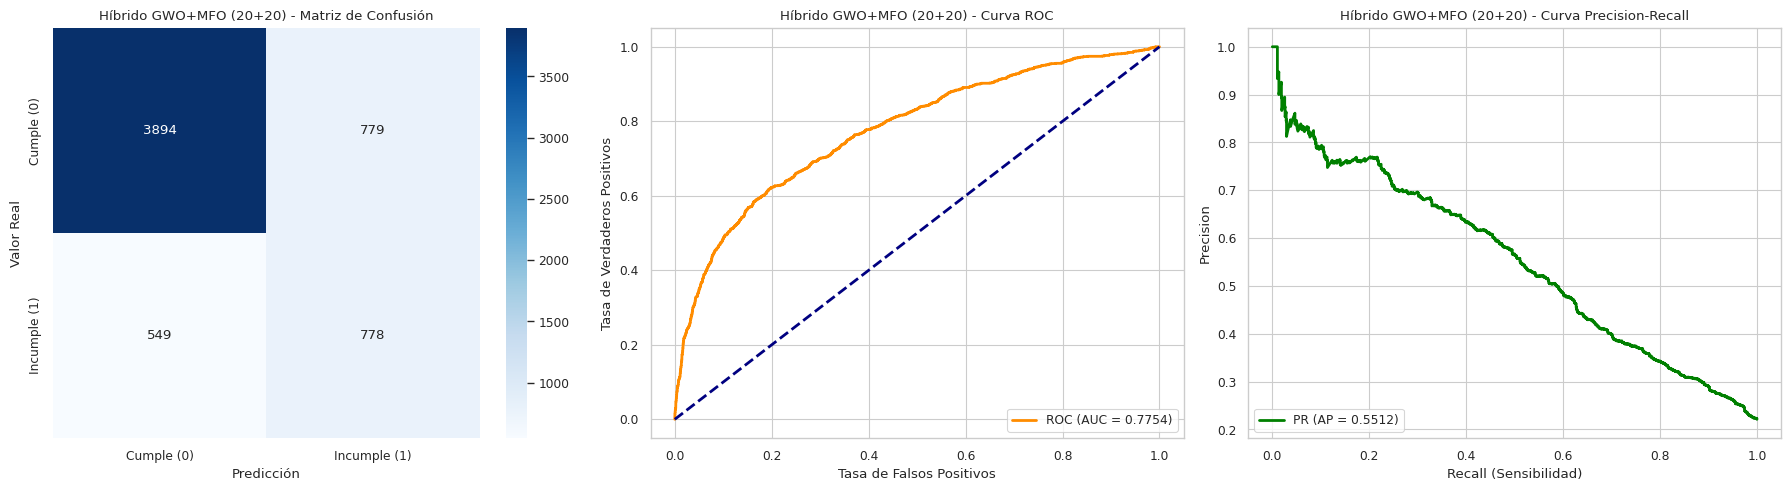

In [13]:
model_hybrid_20 = xgb.XGBClassifier(
    **best_params_hybrid_20, tree_method='hist', device='cuda',
    eval_metric='aucpr', random_state=GLOBAL_SEED, verbosity=0
)
model_hybrid_20.fit(X_train, y_train, verbose=False)

y_pred_hybrid_20 = model_hybrid_20.predict(X_test)
y_prob_hybrid_20 = model_hybrid_20.predict_proba(X_test)[:, 1]
metrics_hybrid_20 = evaluate_model(
    y_test, y_pred_hybrid_20, y_prob_hybrid_20, "Híbrido (20+20)"
)

plot_model_evaluation(y_test, y_pred_hybrid_20, y_prob_hybrid_20, 
                      "Híbrido GWO+MFO (20+20)",
                      save_path=f"{OUTPUT_DIR}/eval_HYB_20_20.png")

# Optimización Híbrida GWO + MFO (50 + 20)

In [14]:
best_params_hybrid_50, t_hyb50, ofe_hyb50 = run_hybrid(
    gwo_epochs=50, mfo_epochs=20, pop_size=20,
    seed=GLOBAL_SEED, label="Híbrido (50+20)"
)
print(f"Mejores hiperparámetros Híbrido (50+20): {best_params_hybrid_50}")

2026/07/24 12:32:25 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=50, pop_size=20)


🐺 FASE 1: GWO (50 épocas) - Híbrido (50+20)


2026/07/24 12:33:02 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44792052715206526, Global best: 0.44792052715206526, Runtime: 17.74187 seconds
2026/07/24 12:33:19 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44792052715206526, Global best: 0.44792052715206526, Runtime: 17.35376 seconds
2026/07/24 12:33:36 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44792052715206526, Global best: 0.44792052715206526, Runtime: 16.30891 seconds
2026/07/24 12:33:56 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.44792052715206526, Global best: 0.44792052715206526, Runtime: 20.30011 seconds
2026/07/24 12:34:15 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44758335367086594, Global best: 0.44758335367086594, Runtime: 19.25146 seconds
2026/07/24 12:34:36 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>P

   Fitness GWO: 0.4443 (1055.2s)
🦋 FASE 2: MFO (20 épocas) - Híbrido (50+20)
   LB_local: [1.322806e+02 3.366600e+00 1.000000e-02 6.000000e-01 8.281000e-01
 2.270700e+00]
   UB_local: [3.322806e+02 6.166600e+00 5.860000e-02 7.274000e-01 9.881000e-01
 3.470700e+00]


2026/07/24 12:50:33 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 1, Current best: 0.44507240063562764, Global best: 0.44507240063562764, Runtime: 16.08502 seconds
2026/07/24 12:50:50 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 2, Current best: 0.44507240063562764, Global best: 0.44507240063562764, Runtime: 16.49060 seconds
2026/07/24 12:51:06 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 3, Current best: 0.44507240063562764, Global best: 0.44507240063562764, Runtime: 15.96002 seconds
2026/07/24 12:51:22 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 4, Current best: 0.4447511892063682, Global best: 0.4447511892063682, Runtime: 16.12564 seconds
2026/07/24 12:51:39 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 5, Current best: 0.44393704225357117, Global best: 0.44393704225357117, Runtime: 17.23874 seconds
2026/07/24 12:51:56 AM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Pro

   Fitness MFO: 0.4438 (356.1s)
   OFEs totales: (50+20) × 20 × 3 = 4200
Mejores hiperparámetros Híbrido (50+20): {'n_estimators': 225, 'max_depth': 5, 'learning_rate': 0.056303580955770156, 'subsample': 0.7265011614370426, 'colsample_bytree': 0.8919437253994467, 'scale_pos_weight': 2.9447445755988637}


# Entrenamiento Final Híbrido (50+20)

--- Híbrido (50+20) ---
PR-AUC: 0.5503 | ROC-AUC: 0.7746 | F1: 0.5414 | Recall: 0.5765 | Acc: 0.7840
TP=765 | FP=734 | TN=3939 | FN=562
💾 Figura guardada: /kaggle/working/resultados_gwo_mfo/eval_HYB_50_20.png


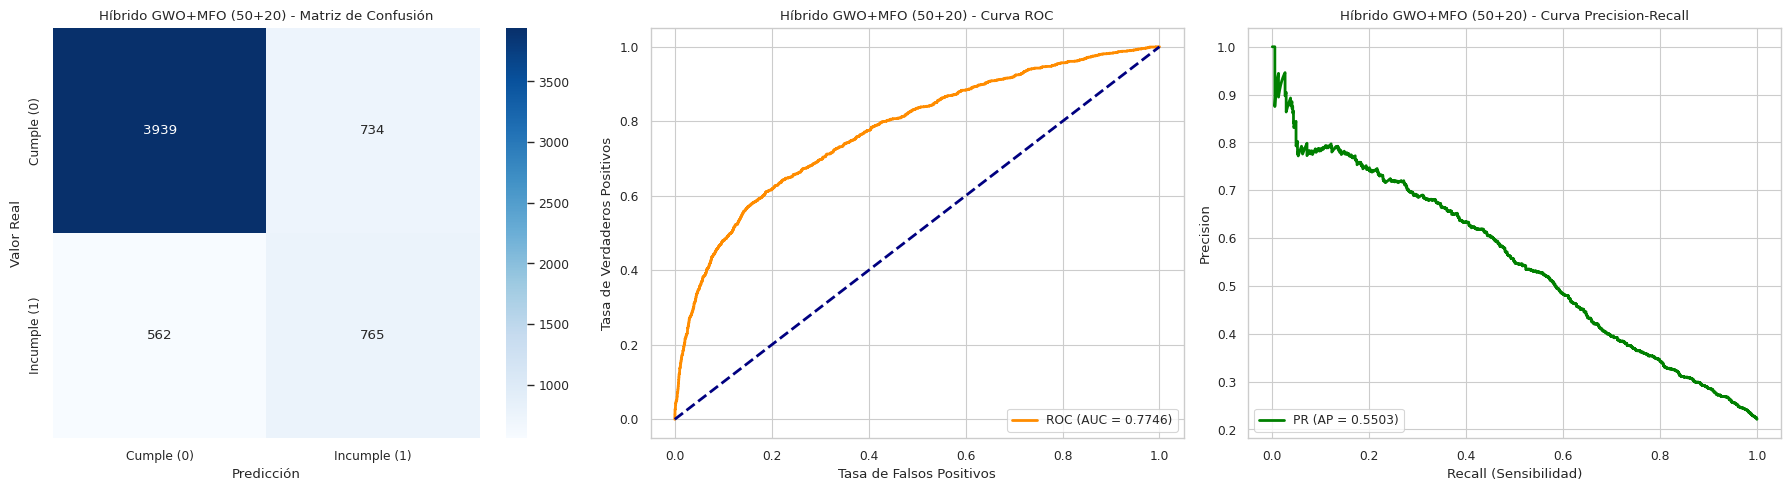

In [15]:
model_hybrid_50 = xgb.XGBClassifier(
    **best_params_hybrid_50, tree_method='hist', device='cuda',
    eval_metric='aucpr', random_state=GLOBAL_SEED, verbosity=0
)
model_hybrid_50.fit(X_train, y_train, verbose=False)

y_pred_hybrid_50 = model_hybrid_50.predict(X_test)
y_prob_hybrid_50 = model_hybrid_50.predict_proba(X_test)[:, 1]
metrics_hybrid_50 = evaluate_model(
    y_test, y_pred_hybrid_50, y_prob_hybrid_50, "Híbrido (50+20)"
)

plot_model_evaluation(y_test, y_pred_hybrid_50, y_prob_hybrid_50,
                      "Híbrido GWO+MFO (50+20)",
                      save_path=f"{OUTPUT_DIR}/eval_HYB_50_20.png")

# Tabla Comparativa de Rendimiento

In [16]:
all_metrics = {
    "XGBoost Base": metrics_base,
    "GWO (20 Iter)": metrics_gwo_20,
    "GWO (50 Iter)": metrics_gwo_50,
    "Híbrido (20+20)": metrics_hybrid_20,
    "Híbrido (50+20)": metrics_hybrid_50,
}

comparison_df = pd.DataFrame(all_metrics).T
comparison_df["Geo-Mean"] = np.sqrt(comparison_df["pr_auc"] * comparison_df["f1"])
comparison_df["Δ PR-AUC (%)"] = ((comparison_df["pr_auc"] / metrics_base["pr_auc"]) - 1) * 100

print("\n📊 TABLA COMPARATIVA")
print(comparison_df[["pr_auc","f1","recall","accuracy","Geo-Mean","Δ PR-AUC (%)"]].to_string())

# P-23: Exportar para el artículo
comparison_df.to_csv(f"{OUTPUT_DIR}/tabla_comparativa.csv")
print(f"\n💾 Tabla exportada: {OUTPUT_DIR}/tabla_comparativa.csv")


📊 TABLA COMPARATIVA
                   pr_auc        f1    recall  accuracy  Geo-Mean  Δ PR-AUC (%)
XGBoost Base     0.540359  0.528993  0.587792  0.768500  0.534646      0.000000
GWO (20 Iter)    0.548433  0.538213  0.565185  0.785500  0.543299      1.494134
GWO (50 Iter)    0.553560  0.549427  0.577995  0.790333  0.551490      2.443012
Híbrido (20+20)  0.551169  0.539528  0.586285  0.778667  0.545318      2.000534
Híbrido (50+20)  0.550305  0.541401  0.576488  0.784000  0.545835      1.840683

💾 Tabla exportada: /kaggle/working/resultados_gwo_mfo/tabla_comparativa.csv


# Análisis de Robustez Estadística (15 ejecuciones)

In [17]:
seeds = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 
         2021, 2223, 2425, 2627, 2829, 3031]

results = {
    "base": [], "gwo_20": [], "gwo_50": [], 
    "hybrid_20": [], "hybrid_50": []
}

print(f"Iniciando análisis de robustez ({len(seeds)} ejecuciones)...")
t_robust_start = time.time()

for i, seed in enumerate(seeds):
    print(f"\n{'='*60}")
    print(f"Ejecución {i+1}/{len(seeds)} (Seed: {seed})")
    print(f"{'='*60}")
    
    # --- Modelo Base ---
    mb = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=base_scale_pos_weight,
        tree_method='hist', device='cuda', eval_metric='aucpr',
        random_state=seed, verbosity=0
    )
    mb.fit(X_train, y_train, verbose=False)
    results["base"].append(
        average_precision_score(y_test, mb.predict_proba(X_test)[:, 1])
    )
    
    # --- GWO 20 ---
    np.random.seed(seed)
    obj_seed = make_objective(seed)
    prob_20 = {"obj_func": obj_seed, 
               "bounds": FloatVar(lb=LB, ub=UB, name="x"), "minmax": "min"}
    g20 = GWO.OriginalGWO(epoch=20, pop_size=20)
    best_g20 = g20.solve(prob_20)
    bp_g20 = extract_params(best_g20.solution)
    bp_g20.update({"tree_method": 'hist', "device": 'cuda', 
                   "eval_metric": 'aucpr', "random_state": seed, "verbosity": 0})
    m_g20 = xgb.XGBClassifier(**bp_g20)
    m_g20.fit(X_train, y_train, verbose=False)  # P-10: verbose=False
    results["gwo_20"].append(
        average_precision_score(y_test, m_g20.predict_proba(X_test)[:, 1])
    )
    
    # --- GWO 50 ---
    np.random.seed(seed)
    g50 = GWO.OriginalGWO(epoch=50, pop_size=20)
    best_g50 = g50.solve(prob_20)
    bp_g50 = extract_params(best_g50.solution)
    bp_g50.update({"tree_method": 'hist', "device": 'cuda',
                   "eval_metric": 'aucpr', "random_state": seed, "verbosity": 0})
    m_g50 = xgb.XGBClassifier(**bp_g50)
    m_g50.fit(X_train, y_train, verbose=False)
    results["gwo_50"].append(
        average_precision_score(y_test, m_g50.predict_proba(X_test)[:, 1])
    )
    
    # --- Híbrido 20+20 ---
    best_sol_20 = best_g20.solution
    LB_l = [max(lb, b - (ub-lb)*0.20) for lb, ub, b in zip(LB, UB, best_sol_20)]
    UB_l = [min(ub, b + (ub-lb)*0.20) for lb, ub, b in zip(LB, UB, best_sol_20)]
    for j, (l, u) in enumerate(zip(LB_l, UB_l)):
        if l >= u:
            mid = (l + u) / 2; LB_l[j] = mid - 0.01; UB_l[j] = mid + 0.01
    prob_mfo_20 = {"obj_func": obj_seed,
                   "bounds": FloatVar(lb=LB_l, ub=UB_l, name="x"), "minmax": "min"}
    np.random.seed(seed + 1)
    mfo_20 = MFO.OriginalMFO(epoch=20, pop_size=20)
    best_m20 = mfo_20.solve(prob_mfo_20)
    bp_m20 = extract_params(best_m20.solution)
    bp_m20.update({"tree_method": 'hist', "device": 'cuda',
                   "eval_metric": 'aucpr', "random_state": seed, "verbosity": 0})
    m_m20 = xgb.XGBClassifier(**bp_m20)
    m_m20.fit(X_train, y_train, verbose=False)
    results["hybrid_20"].append(
        average_precision_score(y_test, m_m20.predict_proba(X_test)[:, 1])
    )
    
    # --- Híbrido 50+20 ---
    best_sol_50 = best_g50.solution
    LB_l50 = [max(lb, b - (ub-lb)*0.20) for lb, ub, b in zip(LB, UB, best_sol_50)]
    UB_l50 = [min(ub, b + (ub-lb)*0.20) for lb, ub, b in zip(LB, UB, best_sol_50)]
    for j, (l, u) in enumerate(zip(LB_l50, UB_l50)):
        if l >= u:
            mid = (l + u) / 2; LB_l50[j] = mid - 0.01; UB_l50[j] = mid + 0.01
    prob_mfo_50 = {"obj_func": obj_seed,
                   "bounds": FloatVar(lb=LB_l50, ub=UB_l50, name="x"), "minmax": "min"}
    np.random.seed(seed + 1)
    mfo_50 = MFO.OriginalMFO(epoch=20, pop_size=20)
    best_m50 = mfo_50.solve(prob_mfo_50)
    bp_m50 = extract_params(best_m50.solution)
    bp_m50.update({"tree_method": 'hist', "device": 'cuda',
                   "eval_metric": 'aucpr', "random_state": seed, "verbosity": 0})
    m_m50 = xgb.XGBClassifier(**bp_m50)
    m_m50.fit(X_train, y_train, verbose=False)
    results["hybrid_50"].append(
        average_precision_score(y_test, m_m50.predict_proba(X_test)[:, 1])
    )
    
    # P-11: Checkpoint cada 5 ejecuciones
    if (i + 1) % 5 == 0:
        with open(f"{OUTPUT_DIR}/robustness_checkpoint.json", "w") as f:
            json.dump({"seeds": seeds[:i+1], "results": results}, f, indent=2)
        print(f"💾 Checkpoint guardado (ejecución {i+1})")

t_robust_total = time.time() - t_robust_start
print(f"\n✅ Análisis de robustez completado en {t_robust_total/3600:.2f} horas")

# Guardado final
with open(f"{OUTPUT_DIR}/robustness_results.json", "w") as f:
    json.dump({"seeds": seeds, "results": results, 
               "total_time_hours": t_robust_total/3600}, f, indent=2)
print(f"💾 Resultados guardados: {OUTPUT_DIR}/robustness_results.json")

Iniciando análisis de robustez (15 ejecuciones)...

Ejecución 1/15 (Seed: 42)


2026/07/24 12:56:00 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=20)
2026/07/24 12:56:41 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44905629288045823, Global best: 0.44905629288045823, Runtime: 19.61209 seconds
2026/07/24 12:56:57 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44905629288045823, Global best: 0.44905629288045823, Runtime: 16.27540 seconds
2026/07/24 12:57:16 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4456667764553961, Global best: 0.4456667764553961, Runtime: 18.36964 seconds
2026/07/24 12:57:40 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4456667764553961, Global best: 0.4456667764553961, Runtime: 24.67295 seconds
2026/07/24 12:58:10 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4456667764553961, Global best: 0.4456667764553961, R


Ejecución 2/15 (Seed: 123)


2026/07/24 01:38:10 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=20)
2026/07/24 01:38:45 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.45135296773462336, Global best: 0.45135296773462336, Runtime: 16.06495 seconds
2026/07/24 01:38:59 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44986567147525297, Global best: 0.44986567147525297, Runtime: 14.43194 seconds
2026/07/24 01:39:16 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44986567147525297, Global best: 0.44986567147525297, Runtime: 16.37296 seconds
2026/07/24 01:39:33 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4489312807417824, Global best: 0.4489312807417824, Runtime: 17.35392 seconds
2026/07/24 01:39:52 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4486892909457423, Global best: 0.4486892909457423,


Ejecución 3/15 (Seed: 456)


...


Ejecución 14/15 (Seed: 2829)


2026/07/24 09:32:34 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=20)
2026/07/24 09:33:10 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.45049796410142884, Global best: 0.45049796410142884, Runtime: 15.89947 seconds
2026/07/24 09:33:24 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4491317903182412, Global best: 0.4491317903182412, Runtime: 13.22183 seconds
2026/07/24 09:33:37 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4491317903182412, Global best: 0.4491317903182412, Runtime: 13.32945 seconds
2026/07/24 09:33:49 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4468701400836996, Global best: 0.4468701400836996, Runtime: 12.51021 seconds
2026/07/24 09:34:04 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4468701400836996, Global best: 0.4468701400836996, Run


Ejecución 15/15 (Seed: 3031)


2026/07/24 10:00:31 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=20, pop_size=20)
2026/07/24 10:01:02 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44808962623231946, Global best: 0.44808962623231946, Runtime: 14.62969 seconds
2026/07/24 10:01:17 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4477293663251585, Global best: 0.4477293663251585, Runtime: 14.95611 seconds
2026/07/24 10:01:36 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4471332190502322, Global best: 0.4471332190502322, Runtime: 19.14921 seconds
2026/07/24 10:01:54 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4471332190502322, Global best: 0.4471332190502322, Runtime: 18.09572 seconds
2026/07/24 10:02:11 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4471332190502322, Global best: 0.4471332190502322, Run

💾 Checkpoint guardado (ejecución 15)

✅ Análisis de robustez completado en 9.60 horas
💾 Resultados guardados: /kaggle/working/resultados_gwo_mfo/robustness_results.json


# Análisis Estadístico Completo (IC 95% + Wilcoxon + Holm-Bonferroni)

In [18]:
# ============================================================
# INTERVALOS DE CONFIANZA 95%
# ============================================================
def ci_95(data):
    n = len(data)
    m = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = t_dist.ppf(0.975, df=n-1)
    return m, m - t_crit * se, m + t_crit * se

print("\n📊 INTERVALOS DE CONFIANZA (95%)")
print(f"{'Modelo':25s} {'Media':>8s} {'IC_inf':>8s} {'IC_sup':>8s} {'Var':>12s}")
print("-" * 65)
for name, key in [("XGBoost Base", "base"), ("GWO (20)", "gwo_20"),
                   ("GWO (50)", "gwo_50"), ("Híbrido (20+20)", "hybrid_20"),
                   ("Híbrido (50+20)", "hybrid_50")]:
    data = results[key]
    m, lo, hi = ci_95(data)
    v = np.var(data, ddof=1)
    print(f"{name:25s} {m:8.4f} {lo:8.4f} {hi:8.4f} {v:12.2e}")

# ============================================================
# SHAPIRO-WILK (justificación de test no paramétrico)
# ============================================================
print("\n📊 SHAPIRO-WILK (normalidad)")
for name, key in [("Base", "base"), ("GWO-20", "gwo_20"), 
                   ("GWO-50", "gwo_50"), ("Híb-20+20", "hybrid_20"),
                   ("Híb-50+20", "hybrid_50")]:
    stat_sw, p_sw = shapiro(results[key])
    normal = "Normal" if p_sw > 0.05 else "No normal"
    print(f"  {name:15s}: W={stat_sw:.4f}, p={p_sw:.4f} → {normal}")

# ============================================================
# WILCOXON + HOLM-BONFERRONI + EFFECT SIZE
# ============================================================
comparisons = [
    ("Híb(20+20) vs Base",       "hybrid_20", "base"),
    ("Híb(50+20) vs Base",       "hybrid_50", "base"),
    ("Híb(20+20) vs GWO(20)",    "hybrid_20", "gwo_20"),
    ("Híb(50+20) vs GWO(50)",    "hybrid_50", "gwo_50"),
    ("Híb(50+20) vs Híb(20+20)", "hybrid_50", "hybrid_20"),
]

n_comp = len(comparisons)
n = len(seeds)
max_W = n * (n + 1) / 2  # = 120

wilcoxon_results = []
for name, key_a, key_b in comparisons:
    W, p = wilcoxon(results[key_a], results[key_b], alternative='greater')
    r_rb = 1 - (2 * W) / max_W
    wilcoxon_results.append((name, W, p, r_rb))

# Holm-Bonferroni: ordenar por p-value
wilcoxon_results.sort(key=lambda x: x[2])

print(f"\n{'='*90}")
print("WILCOXON + HOLM-BONFERRONI + EFFECT SIZE")
print(f"{'='*90}")
print(f"{'Comparación':35s} {'W':>5s} {'p':>10s} {'p_Holm':>10s} {'r_rb':>7s} {'Sig?':>5s}")
print("-" * 90)

for rank, (name, W, p, r_rb) in enumerate(wilcoxon_results):
    p_holm = min(p * (n_comp - rank), 1.0)
    sig = "✅" if p_holm < 0.05 else "❌"
    print(f"{name:35s} {W:5.0f} {p:10.6f} {p_holm:10.6f} {r_rb:7.3f} {sig:>5s}")

# Potencia estadística con n=15
print(f"\n📊 Potencia estadística: n={n}, p_min posible = {1/2**n:.6f}")
print(f"   Con α=0.05 y n=15, se necesita W≥115 para significancia unilateral.")


📊 INTERVALOS DE CONFIANZA (95%)
Modelo                       Media   IC_inf   IC_sup          Var
-----------------------------------------------------------------
XGBoost Base                0.5434   0.5420   0.5448     6.73e-06
GWO (20)                    0.5500   0.5459   0.5540     5.32e-05
GWO (50)                    0.5523   0.5492   0.5553     3.10e-05
Híbrido (20+20)             0.5507   0.5473   0.5542     3.86e-05
Híbrido (50+20)             0.5519   0.5485   0.5553     3.73e-05

📊 SHAPIRO-WILK (normalidad)
  Base           : W=0.9802, p=0.9706 → Normal
  GWO-20         : W=0.7908, p=0.0028 → No normal
  GWO-50         : W=0.9313, p=0.2853 → Normal
  Híb-20+20      : W=0.9570, p=0.6406 → Normal
  Híb-50+20      : W=0.8918, p=0.0715 → Normal

WILCOXON + HOLM-BONFERRONI + EFFECT SIZE
Comparación                             W          p     p_Holm    r_rb  Sig?
------------------------------------------------------------------------------------------
Híb(50+20) vs Base         

# Boxplots PR-AUC

💾 Boxplot guardado: /kaggle/working/resultados_gwo_mfo/Boxplot_PR-AUC_15_Ejecuciones.png


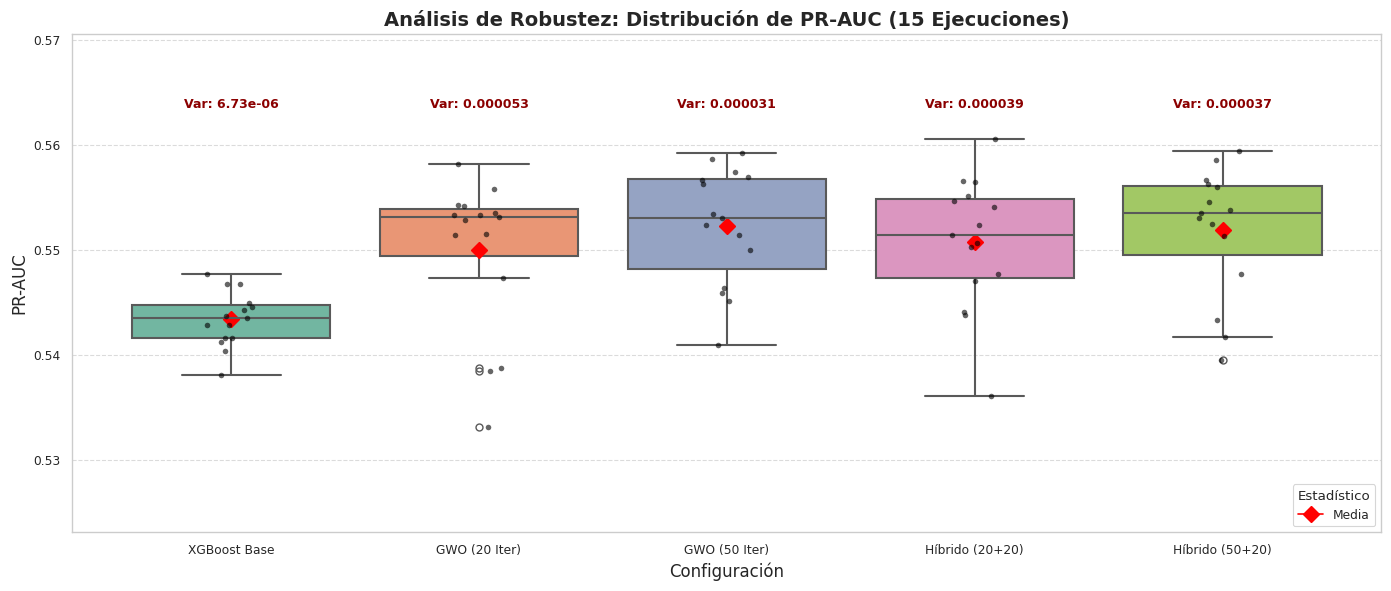

In [19]:
plt.figure(figsize=(14, 6))

df_robust = pd.DataFrame({
    "XGBoost Base": results["base"],
    "GWO (20 Iter)": results["gwo_20"],
    "GWO (50 Iter)": results["gwo_50"],
    "Híbrido (20+20)": results["hybrid_20"],
    "Híbrido (50+20)": results["hybrid_50"]
}).melt(var_name="Modelo", value_name="PR-AUC")

ax = sns.boxplot(data=df_robust, x="Modelo", y="PR-AUC", palette="Set2",
                 linewidth=1.5, fliersize=5)
sns.stripplot(data=df_robust, x="Modelo", y="PR-AUC", color="black",
              size=4, alpha=0.6, jitter=True)

models_list = df_robust["Modelo"].unique()
means_list = [df_robust[df_robust["Modelo"] == m]["PR-AUC"].mean() for m in models_list]
vars_list = [df_robust[df_robust["Modelo"] == m]["PR-AUC"].var() for m in models_list]

for i, (model, mean) in enumerate(zip(models_list, means_list)):
    ax.plot(i, mean, marker='D', color='red', markersize=8,
            label='Media' if i == 0 else "")

plt.title("Análisis de Robustez: Distribución de PR-AUC (15 Ejecuciones)",
          fontsize=14, fontweight='bold')
plt.ylabel("PR-AUC", fontsize=12)
plt.xlabel("Configuración", fontsize=12)
plt.ylim(min(df_robust["PR-AUC"]) - 0.01, max(df_robust["PR-AUC"]) + 0.01)
plt.legend(title="Estadístico", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (model, var, mean_val) in enumerate(zip(models_list, vars_list, means_list)):
    var_text = f'Var: {var:.2e}' if var < 0.00001 else f'Var: {var:.6f}'
    ax.annotate(var_text, xy=(i, mean_val), 
                xytext=(i, max(df_robust["PR-AUC"]) + 0.003),
                ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Boxplot_PR-AUC_15_Ejecuciones.png", 
            dpi=300, bbox_inches='tight')
print(f"💾 Boxplot guardado: {OUTPUT_DIR}/Boxplot_PR-AUC_15_Ejecuciones.png")
plt.show()

# Resumen de Tiempos y OFEs

In [20]:
print("\n📊 RESUMEN DE TIEMPOS Y OFEs")
print(f"{'Método':25s} {'Tiempo (s)':>12s} {'OFEs':>8s}")
print("-" * 50)
print(f"{'GWO (20 iter)':25s} {t_gwo20:12.1f} {20*20*3:8d}")
print(f"{'GWO (50 iter)':25s} {t_gwo50:12.1f} {50*20*3:8d}")
print(f"{'Híbrido (20+20)':25s} {t_hyb20:12.1f} {ofe_hyb20:8d}")
print(f"{'Híbrido (50+20)':25s} {t_hyb50:12.1f} {ofe_hyb50:8d}")
print(f"{'Robustez (total)':25s} {t_robust_total:12.1f} {'N/A':>8s}")


📊 RESUMEN DE TIEMPOS Y OFEs
Método                      Tiempo (s)     OFEs
--------------------------------------------------
GWO (20 iter)                    444.4     1200
GWO (50 iter)                    957.4     3000
Híbrido (20+20)                 1049.0     2400
Híbrido (50+20)                 1411.3     4200
Robustez (total)               34542.5      N/A
